Today's topics:
* indexing DataFrames with `.iloc` and `.loc`
* comparing values with `>`, `<`, `>=`, `<=`, `==`
* boolean masks and filtering

# Cooling superconductors to operating temperature

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/6f/Levitation_meissner.jpg/960px-Levitation_meissner.jpg" alt="Three photographs side by side of a small disc magnet above a black ceramic disc resting in a shallow dish of liquid nitrogen, with a wider gap between the magnet and the disc in each successive frame" width=760/>

Photo by Julien Bobroff and Frederic Bouquet, LPS Orsay, CC BY-SA 3.0, [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Levitation_meissner.jpg).

The black disc is a cuprate in a dish of liquid nitrogen.
When the disc cools below its critical temperature, the magnet levitates above it.

A superconductor operates below its critical temperature, $T_c$.
Liquid helium boils near 4.2 K, while liquid nitrogen boils near 77 K at atmospheric pressure.
Ideally we'd be able to use liquid nitrogen, which is cheap and easy to handle, but most superconductors have $T_c$ below 77 K.
This cuprate is one of the exceptions: liquid nitrogen can cool it below its critical temperature.


<!DOCTYPE svg PUBLIC "-//W3C//DTD SVG 1.1//EN"
  "http://www.w3.org/Graphics/SVG/1.1/DTD/svg11.dtd">


Above: resistance measured while cooling a FeSe thin film grown at Penn State's [2D Crystal Consortium](https://2dcc.psu.edu/).
Below its transition, the measured resistance is approximately zero.
Data package [10.26207/j3vb-gg87](https://doi.org/10.26207/j3vb-gg87), CC BY 4.0.

Today we'll assess: Which reported superconductors can be cooled by liquid nitrogen?

In [1]:
#@title Find the three-column superconductor table (click ▶ to run) { display-mode: "form" }
import os

_file = 'superconductors_l11.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (path for path in (
        f'datasets/{_file}',
        f'../datasets/{_file}',
        f'../../datasets/{_file}',
        f'../../../datasets/{_file}',
    ) if os.path.exists(path)),
    None,
)
source = _local if _local else _github

print(f'Ready to read {_file}')

Ready to read superconductors_l11.csv


## The table

This course table comes from [Hamidieh's superconductivity dataset](https://archive.ics.uci.edu/dataset/464/superconductivty+data), which was derived from the NIMS SuperCon database.
Each row contains a chemical formula, the number of elements in the formula and a reported critical temperature.

In [2]:
import pandas as pd

data = pd.read_csv(source)
display(data.head())

,material,number_of_elements,critical_temp
0,Ba0.2La1.8Cu1O4,4,29.0
1,Ba0.1La1.9Ag0.1Cu0.9O4,5,26.0
2,Ba0.1La1.9Cu1O4,4,19.0
3,Ba0.15La1.85Cu1O4,4,22.0
4,Ba0.3La1.7Cu1O4,4,23.0


In [3]:
print(f"rows:            {len(data):,}")
print(f"unique formulas: {data['material'].nunique():,}")

rows:            21,263
unique formulas: 15,542


The formula count is smaller than the row count because some formulas were reported more than once.
Each row therefore represents a reported measurement, not necessarily a different material.

# Indexing a DataFrame

## Rows by position: `.iloc`

`.iloc` selects by integer position, counting from 0.
It works like a `list` or `array`, so the first row is at position 0, the second at position 1, and so on.

In [4]:
first_record = data.iloc[0]
display(first_record)

material              Ba0.2La1.8Cu1O4
number_of_elements                  4
critical_temp                    29.0
Name: 0, dtype: object

A single position returns the whole row; two positions select a row and then a column. (Just like array!)

In [5]:
print(data.iloc[0, 0])
print(data.iloc[0, 2])

Ba0.2La1.8Cu1O4
29.0


As with a `list`, the slice `0:3` stops before position 3.

In [6]:
display(data.iloc[0:3])

,material,number_of_elements,critical_temp
0,Ba0.2La1.8Cu1O4,4,29.0
1,Ba0.1La1.9Ag0.1Cu0.9O4,5,26.0
2,Ba0.1La1.9Cu1O4,4,19.0


## Rows by label: `.loc`

`.loc` uses the labels printed down the left edge of the table.
They happen to be 0, 1, 2 and so on here, so `.loc` and `.iloc` initially look similar.

The pattern is `data.loc[rows, columns]`.
Before the comma we choose rows, and after it we choose columns.

In [7]:
print(data.loc[0, 'material'])
display(data.loc[0:2, ['material', 'critical_temp']])

Ba0.2La1.8Cu1O4


,material,critical_temp
0,Ba0.2La1.8Cu1O4,29.0
1,Ba0.1La1.9Ag0.1Cu0.9O4,26.0
2,Ba0.1La1.9Cu1O4,19.0


Label slices include the final label, unlike position slices.
The `.loc` selection above contains three rows; `data.iloc[0:2]` would contain two.

Row labels can also be text. Here the formula becomes the index in a separate table, leaving `data` as it is.

In [8]:
by_material = data.set_index('material')
display(by_material.loc['Bi1Sr1Ca1Cu2O', ['critical_temp']])

,critical_temp
material,
Bi1Sr1Ca1Cu2O,110.0
Bi1Sr1Ca1Cu2O,106.0
Bi1Sr1Ca1Cu2O,105.0
Bi1Sr1Ca1Cu2O,80.0


The same formula labels four rows, so `.loc` returns all four.

### [Check your understanding]

1. Use `.iloc` to display the row at position 100.
2. Use `.iloc` to print the `critical_temp` of that same row, using positions only.
3. Use `.loc` to display rows 5 through 10 with only the `material` and `critical_temp` columns.
4. Why did step 3 return six rows instead of five?

# Comparisons

## Comparing two values

A comparison evaluates two values and returns a `bool`: either `True` or `False`.

In [9]:
first_tc = first_record['critical_temp']

print(first_tc)
print(first_tc > 77)

29.0
False


We have been using assignment `=` and arithmetic operators `+`, `-`, `*`, `/`, and `**` frequently.

There are also *comparison operators* that are familiar from mathematics.

The six comparison operators return `True` or `False` (`bool` type).

| Operator | Returns `True` when |
|---|---|
| `>` | the left value is greater than the right |
| `<` | the left value is less than the right |
| `>=` | the left value is greater than or equal to the right |
| `<=` | the left value is less than or equal to the right |
| `==` | the values are equal |
| `!=` | the values are different |

In [10]:
print(first_tc == 29.0)
print(first_tc != 29.0)
print(first_tc >= 29.0)

True
False
True


### Assignment `=` versus equality `==`

A single `=` assigns a value, while `==` compares two values.

In [11]:
x = 2

is_three = x == 3  # a comparison: does x equal 3?
print(is_three)
print(x)  # x is untouched at 2

x = 3  # an assignment: make x equal 3
print(x)

False
2
3


**This one is worth slowing down for.**

Write the comparison with a single `=` between two values and the cell does not run at all.

In [12]:
# EXPECTED-ERROR: this cell fails on purpose -- see the surrounding text
2 = 3

SyntaxError: cannot assign to literal here. Maybe you meant '==' instead of '='? (3610029125.py, line 2)

A `SyntaxError` is the good case: nothing ran, and the mistake is on the screen.

The trickier case is below:

In [13]:
x = 2

result = x == 3  # used the == operator correctly
print(result)

result = x = 3   # missed the second = sign!
print(result)
print(x)

False
3
3


The second one is not an error.
`result = x = 3` is a legal assignment that sets both names to 3, so `result` holds 3 instead of `False`, and `x` is no longer 2.

A comparison that actually runs an assignment is very hard to spot.
The cell runs and prints something that looks plausible.

## Comparing many values at once

A comparison against an `array` is applied to every element (like broadcasting).

In [14]:
import numpy as np

temperatures = np.array([4.2, 30.0, 92.0, 77.0, 138.0])

print(temperatures > 77)

[False False  True False  True]


The result is an array of `bool` with one answer per temperature.
Used inside square brackets, this **mask** keeps the elements marked `True`.

In [15]:
warm = temperatures > 77
print(temperatures[warm])

[ 92. 138.]


A NumPy mask needs one answer per element.
A pandas mask must also have row labels that align with the table.

## Comparing a column

Comparing a `Series` gives us one answer per row.

In [16]:
critical_temp = data['critical_temp']
above_nitrogen = critical_temp > 77

display(above_nitrogen.head())
print(len(above_nitrogen), len(data))  # one answer per row
print(above_nitrogen.dtype)            # bool, so this really is a mask

0    False
1    False
2    False
3    False
4    False
Name: critical_temp, dtype: bool

21263 21263
bool


The equal lengths mean that every row has an answer to the 77 K comparison.
The `bool` dtype is the other half of the check: a mask has to be made of `True` and `False`, not of numbers.

## A `Series` retains its column name

Pulling one column out of a `DataFrame` gives a `Series`, and the `Series` carries the column's name with it.

In [17]:
print(critical_temp.name)

critical_temp


That name can go straight into a label instead of being typed out again.

A plain `array` has no `.name`, so this is something the `DataFrame` gives us.

## Count and fraction

`True` counts as 1 and `False` counts as 0.

In [18]:
print(np.sum(above_nitrogen))
print(np.mean(above_nitrogen))

3895
0.1831820533320792


The mask marks 3,895 records, or 18.3% of the table rows.

# Selecting and interpreting records

## Filtering rows with a mask

Put the mask in the row position of `.loc` to keep the rows marked `True`.

In [19]:
nitrogen_records = data.loc[above_nitrogen]

display(nitrogen_records.head())
print(nitrogen_records.shape)

,material,number_of_elements,critical_temp
16,Y1Ba1.5Ca0.5Cu3O7,5,82.0
30,Yb6Ba1Cu1O,4,78.6
31,Yb1.62La0.18Ba0.18Sr0.02Cu1O,6,79.3
32,Y0.4Ba0.6Cu1O,4,90.0
33,Y0.4Ba0.6Cu1O,4,90.5


(3895, 3)


The row count matches the count we got from `np.sum`.
Columns can be named after the comma, exactly as before.

In [20]:
columns = ['material', 'critical_temp']
display(data.loc[above_nitrogen, columns].head())

,material,critical_temp
16,Y1Ba1.5Ca0.5Cu3O7,82.0
30,Yb6Ba1Cu1O,78.6
31,Yb1.62La0.18Ba0.18Sr0.02Cu1O,79.3
32,Y0.4Ba0.6Cu1O,90.0
33,Y0.4Ba0.6Cu1O,90.5


### [Check your understanding]

1. Build a mask called `below_helium` for records with `critical_temp` below 4.2 K.
2. Use `np.sum` and `np.mean` to report how many records that is, and what fraction of the table.
3. Use `.loc` to keep those rows, and display only the `material` and `critical_temp` columns.
4. Check the shape of the filtered table against your count from step 2.

## Filtering returns a `DataFrame`

In [21]:
print(type(data))
print(type(nitrogen_records))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


The filtered table retains its original row labels, leaving gaps where rows were removed.
`.iloc[0]` still returns the first remaining row because it works by position rather than label.

In [22]:
display(nitrogen_records.iloc[0])

material              Y1Ba1.5Ca0.5Cu3O7
number_of_elements                    5
critical_temp                      82.0
Name: 16, dtype: object

## Filtering a filtered table

Because a filtered table is itself a `DataFrame`, we can filter it again.
The second comparison is written against the smaller table, not against `data`.

In [23]:
few_elements = nitrogen_records['number_of_elements'] <= 4
few_element_records = nitrogen_records.loc[few_elements]

print(few_element_records.shape)
display(few_element_records.head())

(997, 3)


,material,number_of_elements,critical_temp
30,Yb6Ba1Cu1O,4,78.6
32,Y0.4Ba0.6Cu1O,4,90.0
33,Y0.4Ba0.6Cu1O,4,90.5
34,Er0.5Ba0.5Cu1O,4,92.0
35,Tm0.35Ba0.65Cu1O,4,93.2


Applying the second comparison to the smaller table leaves 997 records.

## Describing the selected population

The choice of table determines the population described by a statistic or plot.

In [24]:
nitrogen_k = 77  # liquid nitrogen boils here

print(f"median of all records:       {np.median(data['critical_temp']):.1f} K")
print(f"median above {nitrogen_k} K:           {np.median(nitrogen_records['critical_temp']):.1f} K")

median of all records:       20.0 K
median above 77 K:           90.0 K


The second median describes only the records that passed the 77 K screen.

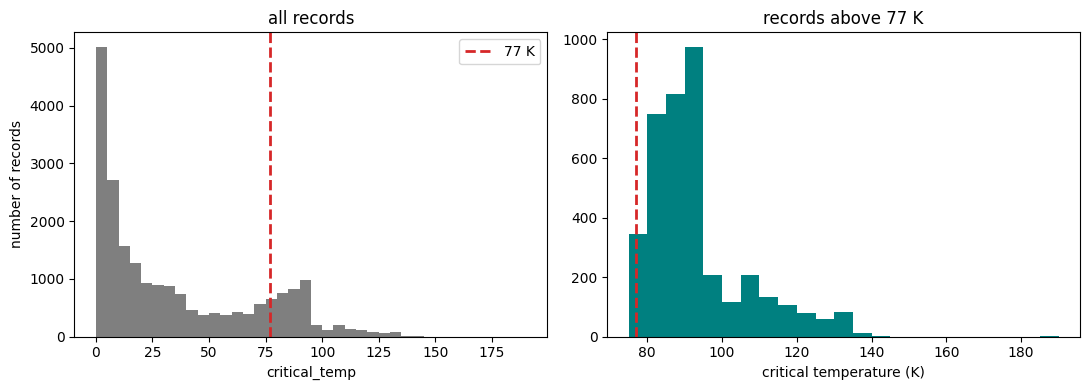

In [25]:
import matplotlib.pyplot as plt

bin_width = 5                                # K per bar
bins_all = np.arange(0, 191, bin_width)      # 0 to 190 K covers the column, which tops out at 185
bins_above = np.arange(75, 191, bin_width)   # start just below the screen so the line has room

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(data['critical_temp'], bins=bins_all, color='tab:gray')
axes[0].axvline(nitrogen_k, color='tab:red', linestyle='--', linewidth=2, label=f'{nitrogen_k} K')
axes[0].set_title('all records')
axes[0].set_xlabel(data['critical_temp'].name)  # the column name, rather than typing it again
axes[0].set_ylabel('number of records')
axes[0].legend()

axes[1].hist(nitrogen_records['critical_temp'], bins=bins_above, color='teal')
axes[1].axvline(nitrogen_k, color='tab:red', linestyle='--', linewidth=2)
axes[1].set_title(f'records above {nitrogen_k} K')
axes[1].set_xlabel('critical temperature (K)')

fig.tight_layout()

> The left panel is labeled `critical_temp`, straight from the column, and the right one says "critical temperature (K)" because we typed it.
> Using `.name` saves typing and reproduces the column name, but that name has no unit. The hand-written label includes (K).

Lower-temperature records make up most of the full table.
Above 77 K, most records lie near the threshold, with fewer at higher temperatures.
This literature-derived table does not represent every possible superconductor.

## Repeated formulas

The formula label we selected with `.loc` gave four reported temperatures: 110, 106, 105 and 80 K.

The four reported temperatures differ even though the formula strings match.
Processing, pressure, and other experimental conditions that may explain the variation are not recorded in these three columns.

# Summary

On indexing DataFrames:
* `.iloc` selects by integer position, and `.loc` selects by label.
* `data.loc[rows, columns]` takes the rows before the comma and the columns after it.

On comparisons:
* A comparison between two values returns `True` or `False`.
* Comparing an `array` or a `Series` returns one Boolean value per element, which we call a mask.
* A mask has to be the same length as the data it selects, and for pandas it has to share its labels.
* `np.sum(mask)` counts matches, and `np.mean(mask)` gives their fraction.
* `.loc[mask]` keeps the marked rows and returns a new `DataFrame` (which can be filtered again).

# Further reading

* VanderPlas, *Python Data Science Handbook*, [Comparisons, Masks, and Boolean Logic](https://jakevdp.github.io/PythonDataScienceHandbook/02.06-boolean-arrays-and-masks.html)
* [Hamidieh superconductivity dataset](https://archive.ics.uci.edu/dataset/464/superconductivty+data), UCI Machine Learning Repository (CC BY 4.0)
* Hamidieh, [*A data-driven statistical model for predicting the critical temperature of a superconductor*](https://doi.org/10.1016/j.commatsci.2018.07.052), *Computational Materials Science* 154, 346–354 (2018)